# Portfolio Weekly Monitor

**Each Monday:** add this week's holdings to `portfolio_rebalances.csv` (full portfolio, weights sum to 1), then run *Kernel → Restart & Run All*.

The notebook shows: performance vs benchmark · tracking error · wiggle room · LLM recommendations.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ── Config (edit these) ───────────────────────────────────────────────────
START_DATE        = pd.Timestamp('2026-09-28')  # first day of the competition
TACTICAL_TARGET   = 0.20   # target fraction of portfolio in individual stock picks
TE_LOW, TE_HIGH   = 0.04, 0.06  # annualised TE target band
TE_SOFT_LIMIT     = 0.07
ANNUAL_CASH_RATE  = 0.00   # CHF cash yield (SARON or 0 for simplicity)
TRADING_DAYS      = 252
OLLAMA_MODEL      = 'llama3.1:8b'  # run: ollama pull llama3.1:8b

# Yahoo Finance FX tickers: 1 foreign unit → CHF
FX_TO_CHF = {'USD': 'USDCHF=X', 'EUR': 'EURCHF=X', 'GBP': 'GBPCHF=X', 'JPY': 'JPYCHF=X'}

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
portfolio_history = pd.read_csv('portfolio_rebalances.csv', parse_dates=['date'])
benchmark_df      = pd.read_csv('benchmark.csv')

# Validate weights
weight_sums = portfolio_history.groupby('date')['weight'].sum()
if not np.allclose(weight_sums.values, 1.0, atol=1e-6):
    raise ValueError(f'Portfolio weights must sum to 1 on every date:\n{weight_sums}')
if not np.isclose(benchmark_df['weight'].sum(), 1.0):
    raise ValueError('Benchmark weights must sum to 1.')

print('Rebalance dates loaded:')
display(weight_sums.rename('sum').to_frame())
print('\nBenchmark:')
display(benchmark_df)

Rebalance dates loaded:


,sum
date,
2026-09-29,1.0000



Benchmark:


,ticker,name,weight,currency
0,VWRD.L,Vanguard FTSE All-World UCITS ETF,0.5500,USD
1,SXLE.L,State Street SPDR S&P U.S. Energy Select Secto...,0.1500,USD
2,AUCHAH.SW,UBS Gold hCHF ETF CHF acc,0.1000,CHF
3,SDIA.L,iShares $ Short Duration Corp Bond UCITS ETF U...,0.1000,USD
4,CASH,CHF cash,0.1000,CHF


In [3]:
all_rows   = pd.concat([portfolio_history[['ticker','currency']], benchmark_df[['ticker','currency']]]).drop_duplicates('ticker')
tickers    = sorted(t for t in all_rows['ticker'].unique() if t != 'CASH')
ccy_map    = dict(zip(all_rows['ticker'], all_rows['currency']))
dl_start   = (START_DATE - pd.tseries.offsets.BDay(420)).date().isoformat()

raw = yf.download(tickers, start=dl_start, auto_adjust=True, progress=False, group_by='column')
prices_local = (raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']].set_axis(tickers, axis=1))
prices_local = prices_local.sort_index().ffill()

needed_ccys = sorted({ccy_map[t] for t in tickers if ccy_map[t] != 'CHF'})
fx = pd.DataFrame(index=prices_local.index)
for ccy in needed_ccys:
    raw_fx = yf.download(FX_TO_CHF[ccy], start=dl_start, auto_adjust=True, progress=False)
    series = raw_fx['Close'].iloc[:, 0] if isinstance(raw_fx.columns, pd.MultiIndex) else raw_fx['Close']
    fx[ccy] = series.reindex(prices_local.index).ffill()

prices_chf = pd.DataFrame(index=prices_local.index)
for t in tickers:
    prices_chf[t] = prices_local[t] * fx[ccy_map[t]] if ccy_map[t] != 'CHF' else prices_local[t]

daily_cash = (1 + ANNUAL_CASH_RATE) ** (1 / TRADING_DAYS) - 1
prices_chf['CASH'] = 100 * (1 + daily_cash) ** np.arange(len(prices_chf))
prices_chf = prices_chf.ffill().dropna()
returns_chf = prices_chf.pct_change().dropna()

print(f'Prices available: {prices_chf.index.min().date()} to {prices_chf.index.max().date()}')

Prices available: 2025-02-18 to 2026-09-29


In [4]:
universe = sorted(set(portfolio_history['ticker']) | set(benchmark_df['ticker']))
analysis_idx = returns_chf.loc[returns_chf.index >= START_DATE].index

# Build daily weight schedule from rebalance history
w_sched = pd.DataFrame(0.0, index=analysis_idx, columns=universe)
for date, grp in portfolio_history.groupby('date'):
    row = grp.set_index('ticker')['weight'].reindex(universe, fill_value=0.0)
    w_sched.loc[w_sched.index >= date] = row.values
w_sched = w_sched.ffill()

bmark_w = benchmark_df.set_index('ticker')['weight'].reindex(universe, fill_value=0.0)

current_w = w_sched.iloc[-1]
active_w  = current_w - bmark_w

alloc_table = pd.DataFrame({
    'portfolio': current_w,
    'benchmark': bmark_w,
    'active':    active_w,
}).sort_values('active', key=np.abs, ascending=False)

print('Current active positions:')
display(alloc_table.style.format('{:.1%}'))

Current active positions:


,portfolio,benchmark,active
VWRD.L,34.8%,55.0%,-20.2%
MU,8.7%,0.0%,8.7%
BESI.AS,5.0%,0.0%,5.0%
QCOM,5.0%,0.0%,5.0%
CASH,11.6%,10.0%,1.6%
SXLE.L,15.0%,15.0%,-0.0%
SDIA.L,10.0%,10.0%,-0.0%
AUCHAH.SW,10.0%,10.0%,-0.0%


In [5]:
rets = returns_chf.reindex(columns=universe).loc[analysis_idx].fillna(0.0)

# lag weights by 1 day to avoid look-ahead
eff_w = w_sched.shift(1)
eff_w.iloc[0] = w_sched.iloc[0]

port_daily  = (rets * eff_w).sum(axis=1)
bmark_daily = (rets * bmark_w).sum(axis=1)
active_daily = port_daily - bmark_daily

nav = pd.DataFrame({
    'Portfolio': (1 + port_daily).cumprod() * 100,
    'Benchmark': (1 + bmark_daily).cumprod() * 100,
})
cum_active = nav['Portfolio'] / nav['Benchmark'] - 1

""" fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

nav.plot(ax=ax1, title='Portfolio vs Benchmark (CHF, start = 100)')
ax1.set_ylabel('NAV'); ax1.grid(alpha=0.25)

cum_active.plot(ax=ax2, color='steelblue', title='Cumulative active return')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Active return'); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'performance.png', dpi=120)
plt.show() """

" fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)\n\nnav.plot(ax=ax1, title='Portfolio vs Benchmark (CHF, start = 100)')\nax1.set_ylabel('NAV'); ax1.grid(alpha=0.25)\n\ncum_active.plot(ax=ax2, color='steelblue', title='Cumulative active return')\nax2.axhline(0, color='black', linewidth=0.8)\nax2.set_ylabel('Active return'); ax2.grid(alpha=0.25)\n\nplt.tight_layout()\nplt.savefig(OUTPUT_DIR / 'performance.png', dpi=120)\nplt.show() "

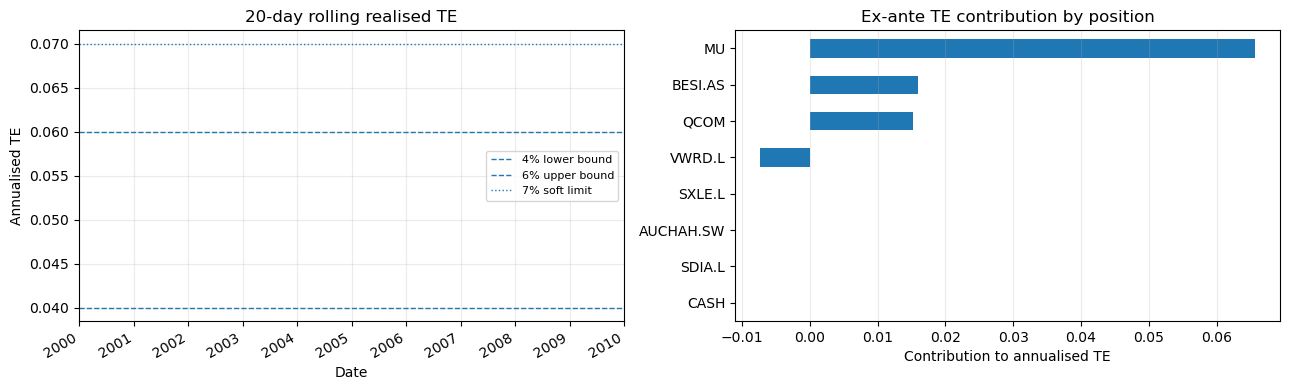

Realised TE (full period): 5.11%
Ex-ante  TE (pre-period cov): 8.96%


In [6]:
def ann_vol(r): return r.std(ddof=1) * np.sqrt(TRADING_DAYS)

realised_te  = ann_vol(active_daily) if len(active_daily) > 1 else float('nan')
rolling_te   = active_daily.rolling(20).std(ddof=1) * np.sqrt(TRADING_DAYS)

# Ex-ante TE from trailing covariance
pre_rets = returns_chf.loc[returns_chf.index < START_DATE].reindex(columns=universe).fillna(0.0).tail(252)
cov_ann  = pre_rets.cov() * TRADING_DAYS
a        = active_w.reindex(universe).fillna(0.0)
ex_ante_var = float(a.values @ cov_ann.values @ a.values)
ex_ante_te  = np.sqrt(max(ex_ante_var, 0))

# TE contribution per position
if ex_ante_te > 0:
    marginal   = cov_ann.values @ a.values
    te_contrib = pd.Series(a.values * marginal / ex_ante_te, index=universe)
else:
    te_contrib = pd.Series(0.0, index=universe)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

rolling_te.plot(ax=ax1, title='20-day rolling realised TE')
for level, style, label in [(TE_LOW,'--','4% lower bound'), (TE_HIGH,'--','6% upper bound'), (TE_SOFT_LIMIT,':','7% soft limit')]:
    ax1.axhline(level, linestyle=style, linewidth=1, label=label)
ax1.set_ylabel('Annualised TE'); ax1.legend(fontsize=8); ax1.grid(alpha=0.25)

te_contrib.sort_values(key=np.abs).plot(kind='barh', ax=ax2, title='Ex-ante TE contribution by position')
ax2.set_xlabel('Contribution to annualised TE'); ax2.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tracking_error.png', dpi=120)
plt.show()

print(f'Realised TE (full period): {realised_te:.2%}')
print(f'Ex-ante  TE (pre-period cov): {ex_ante_te:.2%}')

In [7]:
latest = portfolio_history[portfolio_history['date'] == portfolio_history['date'].max()].copy()
tactical = latest[latest['sleeve'] == 'Tactical equity']
deployed   = tactical['weight'].sum()
wiggle     = TACTICAL_TARGET - deployed

print('=== TACTICAL SLEEVE ===')
print(f"  Target allocation : {TACTICAL_TARGET:.1%}")
print(f"  Currently deployed: {deployed:.1%}")
flag = 'available to deploy' if wiggle >= 0 else 'OVER-ALLOCATED'
print(f"  Wiggle room       : {wiggle:+.1%}  ({flag})")
print()
display(
    tactical[['ticker','name','weight']]
    .assign(weight=lambda d: d['weight'].map('{:.2%}'.format))
    .rename(columns={'weight':'deployed_weight'})
    .reset_index(drop=True)
)

te_headroom = TE_SOFT_LIMIT - ex_ante_te
print(f'=== TE BUDGET ===')
print(f'  Ex-ante TE    : {ex_ante_te:.2%}')
print(f'  Target band   : {TE_LOW:.0%} – {TE_HIGH:.0%}')
print(f'  Headroom to soft limit: {te_headroom:+.2%}')
if te_headroom < 0:
    print('  *** Past soft limit — reduce concentrated positions ***')
elif ex_ante_te < TE_LOW:
    print('  Below target band — consider using more of the tactical sleeve')

=== TACTICAL SLEEVE ===
  Target allocation : 20.0%
  Currently deployed: 18.7%
  Wiggle room       : +1.3%  (available to deploy)



,ticker,name,deployed_weight
0,MU,Micron Technology,8.74%
1,QCOM,Qualcomm,4.95%
2,BESI.AS,BE Semiconductor Industries,4.98%


=== TE BUDGET ===
  Ex-ante TE    : 8.96%
  Target band   : 4% – 6%
  Headroom to soft limit: -1.96%
  *** Past soft limit — reduce concentrated positions ***


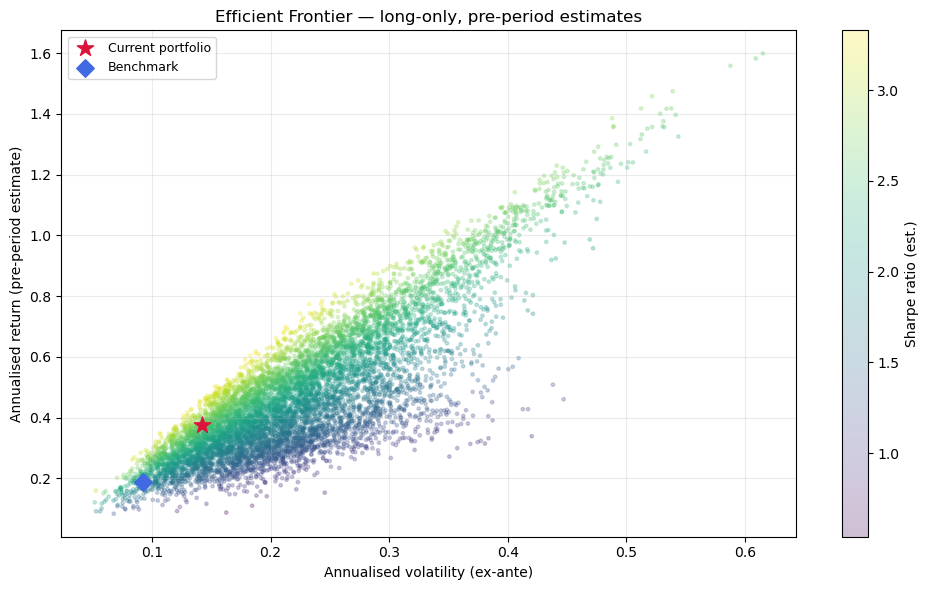

In [8]:
# ── Efficient Frontier (Monte Carlo) ─────────────────────────────────────
# Uses pre-competition trailing 252-day data for return/covariance estimates.
# Long-only, fully-invested portfolios only (Dirichlet samples).

ann_ret  = pre_rets.mean() * TRADING_DAYS
cov_vals = cov_ann.reindex(universe, axis=0).reindex(universe, axis=1).values
mu_vals  = ann_ret.reindex(universe).fillna(0).values

rng     = np.random.default_rng(42)
n_sim   = 8000
w_all   = rng.dirichlet(np.ones(len(universe)), size=n_sim)
r_all   = w_all @ mu_vals
v_all   = np.sqrt(np.einsum('ij,jk,ik->i', w_all, cov_vals, w_all))
sr_all  = np.where(v_all > 0, r_all / v_all, 0)

def point_stats(w):
    wv = w.reindex(universe).fillna(0).values
    return float(wv @ mu_vals), float(np.sqrt(wv @ cov_vals @ wv))

port_r,  port_v  = point_stats(current_w)
bmark_r, bmark_v = point_stats(bmark_w)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(v_all, r_all, c=sr_all, cmap='viridis', alpha=0.25, s=6)
plt.colorbar(sc, ax=ax, label='Sharpe ratio (est.)')
ax.scatter(port_v,  port_r,  color='crimson',   s=150, zorder=5, marker='*', label='Current portfolio')
ax.scatter(bmark_v, bmark_r, color='royalblue', s=80,  zorder=5, marker='D', label='Benchmark')
ax.set_xlabel('Annualised volatility (ex-ante)')
ax.set_ylabel('Annualised return (pre-period estimate)')
ax.set_title('Efficient Frontier — long-only, pre-period estimates')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'efficient_frontier.png', dpi=120)
plt.show()

In [9]:
import ollama

def _pct(v): return 'N/A' if v != v else f'{v:.2%}'
def _f2(v):  return 'N/A' if v != v else f'{v:.2f}'

port_ret   = nav['Portfolio'].iloc[-1] / 100 - 1
bmark_ret  = nav['Benchmark'].iloc[-1] / 100 - 1
active_ret = port_ret - bmark_ret
ann_active = active_daily.mean() * TRADING_DAYS
ir = ann_active / realised_te if realised_te > 0 else float('nan')

summary = pd.DataFrame([
    ('Portfolio return since start',    port_ret),
    ('Benchmark return since start',    bmark_ret),
    ('Active return since start',       active_ret),
    ('Realised tracking error',         realised_te),
    ('Ex-ante tracking error',          ex_ante_te),
    ('Information ratio',               ir),
    ('Portfolio annualised vol',        ann_vol(port_daily)),
    ('Benchmark annualised vol',        ann_vol(bmark_daily)),
], columns=['Metric', 'Value'])

display(summary.style.format({'Value': lambda v: _pct(v)}))

# Save outputs
summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False)
alloc_table.to_csv(OUTPUT_DIR / 'active_weights.csv')
pd.DataFrame({'portfolio': port_daily, 'benchmark': bmark_daily, 'active': active_daily,
              'port_nav': nav['Portfolio'], 'bmark_nav': nav['Benchmark'],
              'rolling_te': rolling_te}).to_csv(OUTPUT_DIR / 'daily_performance.csv')

# ── LLM recommendations ───────────────────────────────────────────────────
top_active = alloc_table.head(6)['active'].map(lambda x: f'{x:+.1%}').to_string()
top_te     = te_contrib.abs().nlargest(6).map(lambda x: f'{x:.2%}').to_string()

if   ex_ante_te > TE_HIGH:   te_status = f'ABOVE {TE_HIGH:.0%} target -- risk is elevated'
elif ex_ante_te < TE_LOW:    te_status = f'below {TE_LOW:.0%} lower bound -- unused budget'
else:                        te_status = f'within {TE_LOW:.0%}-{TE_HIGH:.0%} target band'

prompt = (
    'You are a concise portfolio risk advisor for a 6-week investment competition.\n\n'
    f'BENCHMARK: 55% VWRD.L / 15% SXLE.L / 10% AUCHAH.SW / 10% SDIA.L / 10% CHF cash.\n'
    f'TE TARGET: {TE_LOW:.0%}-{TE_HIGH:.0%} annualised. Soft limit {TE_SOFT_LIMIT:.0%}.\n\n'
    f'TODAY: {pd.Timestamp.today().date()}\n'
    f'Ex-ante TE : {_pct(ex_ante_te)} ({te_status})\n'
    f'Realised TE: {_pct(realised_te)}\n'
    f'Active return since start: {_pct(active_ret)}\n'
    f'Information ratio: {_f2(ir)}\n\n'
    f'ACTIVE WEIGHTS (portfolio minus benchmark):\n{top_active}\n\n'
    f'TOP TE CONTRIBUTORS:\n{top_te}\n\n'
    f'TACTICAL SLEEVE: target {TACTICAL_TARGET:.0%}, deployed {deployed:.1%}, wiggle room {wiggle:+.1%}\n\n'
    'Give 3-5 specific, actionable recommendations for THIS WEEK. '
    'Each: one sentence action + one sentence rationale. Numbered list, no headers, no generic advice.'
)

print('=== WEEKLY RECOMMENDATIONS ===')
try:
    resp = ollama.chat(model=OLLAMA_MODEL, messages=[{'role': 'user', 'content': prompt}])
    print(resp.message.content)
except Exception as e:
    print(f'Ollama not running or model not pulled.  Fix: ollama pull {OLLAMA_MODEL}')
    print(f'Error: {e}')

,Metric,Value
0,Portfolio return since start,0.00%
1,Benchmark return since start,-0.13%
2,Active return since start,0.13%
3,Realised tracking error,5.11%
4,Ex-ante tracking error,8.96%
5,Information ratio,322.19%
6,Portfolio annualised vol,0.00%
7,Benchmark annualised vol,5.11%


=== WEEKLY RECOMMENDATIONS ===
Here are the recommendations:

1. Reduce VWRD.L by -2% and redeploy to CASH, as its underweight position is a significant drag on performance with only 0.73% contribution.
Its reduced allocation would help to lower portfolio risk and free up capacity for other areas.

2. Increase TACTICAL SLEEVE by +1.7%, utilizing the available wiggle room to target 20% allocation, as this sleeve has shown resilience in times of market stress.
This move would not only meet the tactical sleeve's target but also provide an additional buffer against unexpected market downturns.

3. Sell MU and redeploy -4.5% from its overweight position to VWRD.L, reducing excessive exposure to a single stock with high TE contribution (6.57%) relative to overall portfolio.
This rebalancing would help to distribute risk more evenly across the portfolio.
